# Figure: transition curves by end-use profile

This notebook uses `cloglog_data_processed.rds` and fitted primary models saved by Figure 2. Duration curves are constructed in calendar years and transformed internally to the standardised model scale. Sector panels use the **Core + macro controls + year FE** specification, while the any-end-use panel uses the **Core + macro controls + year FE + any enduse** specification.

Run Figure 2 first so that `waterfall_results.rds` is available.

The final section generates **Supplementary Figure S3: Competing risk model Demand** from `multinomial_competing_risk_results.rds`. Run `Discrete-Time-Multinomial-Competing-Risk-Model.ipynb` first.

The fitted country/macro models used here inherit the governance control selected in the master pipeline (`Governance_Score`, `Ease_of_doing_business`, or none).


In [1]:
# Use the same project/data directory in standalone and master-run execution.
# With H2_PROJECT_DIR unset, run from the folder containing Data/ and the RDS files.
project_dir <- Sys.getenv("H2_PROJECT_DIR", unset = getwd())
project_dir <- normalizePath(project_dir, winslash = "/", mustWork = TRUE)
setwd(project_dir)


In [2]:
# ==============================================================================
# Packages and Figure2 inputs
# ==============================================================================

required_packages <- c(
  "dplyr",
  "tidyr",
  "purrr",
  "sandwich",
  "ggplot2",
  "ggsci",
  "scales",
  "patchwork",
  "MASS"
)

missing_packages <- required_packages[
  !vapply(
    required_packages,
    requireNamespace,
    logical(1),
    quietly = TRUE
  )
]

if (length(missing_packages) > 0) {
  stop(
    paste0(
      "Missing packages: ",
      paste(missing_packages, collapse = ", "),
      ". Install them before running this notebook."
    )
  )
}

invisible(
  lapply(
    required_packages,
    library,
    character.only = TRUE
  )
)

set.seed(123)


# ------------------------------------------------------------------------------
# Load the shared Figure2 data
# ------------------------------------------------------------------------------

data_file <- "cloglog_data_processed.rds"

if (!file.exists(data_file)) {
  stop(
    paste0(
      "The Figure2 data file '",
      data_file,
      "' was not found. Run Figure2 first or place the file in the working directory."
    )
  )
}

cloglog_data <- readRDS(data_file)

# ------------------------------------------------------------------------------
# Load the exact fitted models produced by Figure2
# ------------------------------------------------------------------------------

model_results_file <- "waterfall_results.rds"

if (!file.exists(model_results_file)) {
  stop(
    paste0(
      "The Figure2 model-results file '",
      model_results_file,
      "' was not found. Run Figure2 before this notebook."
    )
  )
}

figure2_results <- readRDS(model_results_file)

transition_names <- c(
  "Concept -> Progress",
  "Feasibility -> Progress",
  "FID -> Progress"
)

grouped_model_name <- "Core + macro controls + year FE"
any_enduse_model_name <- "Core + macro controls + year FE + any enduse"

extract_figure2_models <- function(
    results,
    transitions,
    model_name
) {
  extracted_models <- lapply(
    transitions,
    function(transition_name) {
      transition_models <- results$models[[transition_name]]

      if (is.null(transition_models)) {
        stop(
          paste0(
            "Transition '",
            transition_name,
            "' was not found in ",
            model_results_file,
            "."
          )
        )
      }

      model_obj <- transition_models[[model_name]]

      if (is.null(model_obj) || is.null(model_obj$model)) {
        stop(
          paste0(
            "Model '",
            model_name,
            "' was not available for ",
            transition_name,
            "."
          )
        )
      }

      model_obj
    }
  )

  names(extracted_models) <- transitions

  list(
    models = extracted_models
  )
}

cloglog_results_grouped_full <- extract_figure2_models(
  results = figure2_results,
  transitions = transition_names,
  model_name = grouped_model_name
)

cloglog_results_any_full <- extract_figure2_models(
  results = figure2_results,
  transitions = transition_names,
  model_name = any_enduse_model_name
)


# ------------------------------------------------------------------------------
# Figure settings and plotted end-use indicators
# ------------------------------------------------------------------------------

time_var <- "prev_time_in_status"
raw_time_var <- "prev_time_in_status_raw"
n_draws <- 300
conf_level <- 0.90

enduse_vars_model <- c(
  "enduse_industrial",
  "enduse_transport",
  "enduse_chemicals",
  "enduse_power",
  "enduse_other"
)

grouped_model_terms <- unique(
  unlist(
    lapply(
      cloglog_results_grouped_full$models,
      function(model_obj) {
        gsub(
          "`",
          "",
          attr(
            stats::terms(model_obj$model),
            "term.labels"
          )
        )
      }
    ),
    use.names = FALSE
  )
)

enduse_vars_model <- enduse_vars_model[
  enduse_vars_model %in% grouped_model_terms
]

if (length(enduse_vars_model) == 0) {
  stop(
    "The Figure2 grouped-end-use model contains no plotted end-use indicators."
  )
}


enduse_vars_plot <- setdiff(
  enduse_vars_model,
  "enduse_other"
)

enduse_labels <- c(
  enduse_industrial = "Industrial",
  enduse_transport = "Transport",
  enduse_chemicals = "Chemicals",
  enduse_power = "Power",
  enduse_other = "Other"
)

curve_levels_any <- c(
  "No recorded end-use",
  "At least one recorded end-use"
)

curve_levels_grouped <- unname(
  enduse_labels[enduse_vars_plot]
)

curve_cols_any <- ggsci::pal_npg()(length(curve_levels_any))
names(curve_cols_any) <- curve_levels_any

curve_cols_grouped <- ggsci::pal_npg()(length(curve_levels_grouped))
names(curve_cols_grouped) <- curve_levels_grouped

base_theme <- theme_minimal(base_size = 12.75) +
  theme(
    panel.grid = element_blank(),
    panel.border = element_blank(),
    axis.line.x.bottom = element_line(colour = "black", linewidth = 0.3),
    axis.line.y.left = element_line(colour = "black", linewidth = 0.3),
    axis.ticks.x = element_line(colour = "black", linewidth = 0.3),
    axis.ticks.y = element_line(colour = "black", linewidth = 0.3),
    axis.ticks.length = unit(1.5, "mm"),
    plot.title = element_text(
      hjust = 0,
      face = "plain",
      size = 14.25,
      margin = margin(b = 4)
    ),
    axis.text = element_text(size = 12),
    axis.title = element_text(size = 12.75),
    legend.title = element_text(size = 12.75),
    legend.text = element_text(size = 12),
    legend.key.size = unit(0.42, "cm"),
    legend.spacing.y = unit(0.08, "cm"),
    legend.margin = margin(0, 0, 0, 0),
    plot.margin = margin(6, 6, 6, 6)
  )

make_psd <- function(x) {
  x <- (x + t(x)) / 2
  x[!is.finite(x)] <- 0
  
  eig <- eigen(x, symmetric = TRUE)
  eig$values <- pmax(eig$values, .Machine$double.eps)
  
  eig$vectors %*%
    diag(eig$values, nrow = length(eig$values)) %*%
    t(eig$vectors)
}

make_coef_draws <- function(model, model_data, n_draws = 300) {
  beta_hat <- stats::coef(model)
  beta_hat <- beta_hat[is.finite(beta_hat)]
  
  vcov_mat <- sandwich::vcovCL(
    model,
    cluster = ~ reference,
    data = model_data
  )
  
  coef_names <- intersect(names(beta_hat), rownames(vcov_mat))
  beta_hat <- beta_hat[coef_names]
  vcov_mat <- vcov_mat[coef_names, coef_names, drop = FALSE]
  vcov_mat <- make_psd(vcov_mat)
  
  draws <- MASS::mvrnorm(
    n = n_draws,
    mu = beta_hat,
    Sigma = vcov_mat
  )
  
  draws <- as.matrix(draws)
  colnames(draws) <- names(beta_hat)
  draws
}

predict_individual_hazard_draws <- function(
    model,
    pred_data,
    coef_draws
) {
  coef_names <- colnames(coef_draws)

  beta_hat <- stats::coef(model)
  beta_hat <- beta_hat[coef_names]

  x_mat <- stats::model.matrix(
    stats::delete.response(stats::terms(model)),
    data = pred_data
  )

  missing_cols <- setdiff(
    coef_names,
    colnames(x_mat)
  )

  if (length(missing_cols) > 0) {
    missing_mat <- matrix(
      0,
      nrow = nrow(x_mat),
      ncol = length(missing_cols)
    )

    colnames(missing_mat) <- missing_cols

    x_mat <- cbind(
      x_mat,
      missing_mat
    )
  }

  x_mat <- x_mat[, coef_names, drop = FALSE]
  linkinv <- stats::family(model)$linkinv

  hazard_hat <- as.numeric(
    linkinv(
      drop(x_mat %*% beta_hat)
    )
  )

  eta_draws <- x_mat %*%
    t(
      coef_draws[, coef_names, drop = FALSE]
    )

  hazard_draws <- matrix(
    linkinv(as.numeric(eta_draws)),
    nrow = nrow(eta_draws),
    ncol = ncol(eta_draws)
  )

  list(
    hazard_hat = hazard_hat,
    hazard_draws = hazard_draws
  )
}


make_standardised_cloglog_curve <- function(
    model,
    pred_base,
    time_grid,
    time_scale,
    coef_draws,
    time_var = "prev_time_in_status",
    raw_time_var = "prev_time_in_status_raw",
    conf_level = 0.90
) {
  if (nrow(pred_base) == 0) {
    return(NULL)
  }

  alpha <- 1 - conf_level
  number_of_draws <- nrow(coef_draws)

  survival_hat <- rep(
    1,
    nrow(pred_base)
  )

  survival_draws <- matrix(
    1,
    nrow = nrow(pred_base),
    ncol = number_of_draws
  )

  annual_hazard <- numeric(
    length(time_grid)
  )

  cumulative_hat <- numeric(
    length(time_grid)
  )

  cumulative_draw_mat <- matrix(
    NA_real_,
    nrow = length(time_grid),
    ncol = number_of_draws
  )

  for (i in seq_along(time_grid)) {
    pred_data <- pred_base
    pred_data[[raw_time_var]] <- time_grid[i]
    pred_data[[time_var]] <- apply_time_scale(
      time_raw = time_grid[i],
      time_scale = time_scale
    )

    pred <- predict_individual_hazard_draws(
      model = model,
      pred_data = pred_data,
      coef_draws = coef_draws
    )

    hazard_hat <- pmin(
      pmax(pred$hazard_hat, 0),
      1
    )

    hazard_draws <- pmin(
      pmax(pred$hazard_draws, 0),
      1
    )

    survival_hat <- survival_hat * (
      1 - hazard_hat
    )

    survival_draws <- survival_draws * (
      1 - hazard_draws
    )

    annual_hazard[i] <- mean(
      hazard_hat,
      na.rm = TRUE
    )

    cumulative_hat[i] <- mean(
      1 - survival_hat,
      na.rm = TRUE
    )

    cumulative_draw_mat[i, ] <- colMeans(
      1 - survival_draws,
      na.rm = TRUE
    )
  }

  ci_mat <- t(
    apply(
      cumulative_draw_mat,
      1,
      stats::quantile,
      probs = c(
        alpha / 2,
        1 - alpha / 2
      ),
      na.rm = TRUE
    )
  )

  dplyr::bind_rows(
    tibble::tibble(
      time = 0,
      annual_hazard = NA_real_,
      cumulative_transition_probability = 0,
      conf_low = 0,
      conf_high = 0
    ),
    tibble::tibble(
      time = time_grid,
      annual_hazard = annual_hazard,
      cumulative_transition_probability = cumulative_hat,
      conf_low = ci_mat[, 1],
      conf_high = ci_mat[, 2]
    )
  )
}


# Build the x-axis in calendar years and recover the exact linear mapping from
# the stored raw duration to the covariate scale used in the fitted model.
make_time_grid <- function(
    model_data,
    time_var,
    raw_time_var = "prev_time_in_status_raw"
) {
  if (!all(c(time_var, raw_time_var) %in% names(model_data))) {
    stop(
      paste0(
        "The fitted model data must contain both '",
        time_var,
        "' and '",
        raw_time_var,
        "'. Re-run Data Preparation and Figure2."
      )
    )
  }

  max_time <- max(
    model_data[[raw_time_var]],
    na.rm = TRUE
  )

  if (!is.finite(max_time) || max_time < 1) {
    return(NULL)
  }

  seq(
    from = 1,
    to = ceiling(max_time),
    by = 1
  )
}

get_time_scale <- function(
    model_data,
    time_var,
    raw_time_var = "prev_time_in_status_raw"
) {
  time_mapping <- model_data %>%
    dplyr::transmute(
      time_model = as.numeric(.data[[time_var]]),
      time_raw = as.numeric(.data[[raw_time_var]])
    ) %>%
    dplyr::filter(
      is.finite(time_model),
      is.finite(time_raw)
    ) %>%
    dplyr::distinct()

  if (dplyr::n_distinct(time_mapping$time_raw) < 2) {
    stop("At least two raw duration values are required to recover the model scale.")
  }

  mapping_model <- stats::lm(
    time_model ~ time_raw,
    data = time_mapping
  )

  c(
    intercept = unname(stats::coef(mapping_model)[[1]]),
    slope = unname(stats::coef(mapping_model)[[2]])
  )
}

apply_time_scale <- function(
    time_raw,
    time_scale
) {
  unname(
    time_scale[["intercept"]] +
      time_scale[["slope"]] * time_raw
  )
}

make_target_time_grid <- function(
    model_data,
    time_var,
    target_enduse,
    raw_time_var = "prev_time_in_status_raw"
) {
  target_data <- model_data %>%
    dplyr::filter(
      !is.na(.data[[target_enduse]]),
      .data[[target_enduse]] == 1
    )

  make_time_grid(
    model_data = target_data,
    time_var = time_var,
    raw_time_var = raw_time_var
  )
}

make_step_ribbon_data <- function(data, group_vars) {
  
  if (nrow(data) == 0) {
    return(data)
  }
  
  value_cols <- c(
    "annual_hazard",
    "cumulative_transition_probability",
    "conf_low",
    "conf_high"
  )
  
  data %>%
    dplyr::arrange(dplyr::across(dplyr::all_of(c(group_vars, "time")))) %>%
    dplyr::group_by(dplyr::across(dplyr::all_of(group_vars))) %>%
    dplyr::group_modify(function(.x, .y) {
      
      .x <- .x %>%
        dplyr::arrange(time)
      
      if (nrow(.x) <= 1) {
        return(.x)
      }
      
      out <- .x[1, , drop = FALSE]
      
      for (i in 2:nrow(.x)) {
        previous_row <- .x[i - 1, , drop = FALSE]
        current_row <- .x[i, , drop = FALSE]
        
        step_row <- current_row
        step_row[value_cols] <- previous_row[value_cols]
        
        out <- dplyr::bind_rows(
          out,
          step_row,
          current_row
        )
      }
      
      out
    }) %>%
    dplyr::ungroup()
}

# ------------------------------------------------------------------------------
# Generate end-use versus no-end-use transition curves
#
# The left facet uses the separate any-end-use model and compares predictions
# with any_enduse fixed to 1 versus 0 across the same estimation sample.
#
# The four sector facets use the grouped end-use model. For each solid curve,
# the indicated end-use is fixed to 1 and all other end-use indicators are fixed
# to 0. The dashed reference fixes every end-use indicator to 0. This common
# no-end-use reference is repeated across all four sector facets.
# ------------------------------------------------------------------------------

make_any_enduse_curve_data <- function(
    cloglog_results,
    transition_name,
    time_var = "prev_time_in_status",
    n_draws = 300,
    conf_level = 0.90
) {
  model_obj <- cloglog_results$models[[transition_name]]

  if (is.null(model_obj)) {
    return(NULL)
  }

  model <- model_obj$model
  model_data <- model_obj$data
  outcome <- all.vars(stats::formula(model))[[1]]

  model_terms <- gsub(
    "`",
    "",
    attr(stats::terms(model), "term.labels")
  )

  if (!"any_enduse" %in% model_terms) {
    return(NULL)
  }

  if (!time_var %in% names(model_data)) {
    return(NULL)
  }

  time_grid <- make_time_grid(
    model_data = model_data,
    time_var = time_var
  )

  if (is.null(time_grid)) {
    return(NULL)
  }

  time_scale <- get_time_scale(
    model_data = model_data,
    time_var = time_var,
    raw_time_var = raw_time_var
  )

  coef_draws <- make_coef_draws(
    model = model,
    model_data = model_data,
    n_draws = n_draws
  )

  number_of_draws <- nrow(coef_draws)

  make_curve <- function(any_enduse_value) {
    pred_base <- model_data
    pred_base$any_enduse <- any_enduse_value

    make_standardised_cloglog_curve(
      model = model,
      pred_base = pred_base,
      time_grid = time_grid,
      time_scale = time_scale,
      coef_draws = coef_draws,
      time_var = time_var,
      raw_time_var = raw_time_var,
      conf_level = conf_level
    )
  }

  n_project_years <- sum(
    model_data$any_enduse == 1,
    na.rm = TRUE
  )

  n_transitions <- sum(
    model_data[[outcome]] == 1 & model_data$any_enduse == 1,
    na.rm = TRUE
  )

  selected_curve <- make_curve(
    any_enduse_value = 1
  ) %>%
    dplyr::mutate(
      transition = transition_name,
      facet_label = "Any recorded end-use",
      target_enduse = "any_enduse",
      curve_type = "Selected group",
      reference_label = "No recorded end-use",
      n_project_years = n_project_years,
      n_transitions = n_transitions
    )

  reference_curve <- make_curve(
    any_enduse_value = 0
  ) %>%
    dplyr::mutate(
      transition = transition_name,
      facet_label = "Any recorded end-use",
      target_enduse = "any_enduse",
      curve_type = "No end-use reference",
      reference_label = "No recorded end-use",
      n_project_years = n_project_years,
      n_transitions = n_transitions
    )

  dplyr::bind_rows(
    selected_curve,
    reference_curve
  )
}

make_grouped_enduse_curve_data <- function(
    cloglog_results,
    transition_name,
    enduse_vars,
    all_enduse_vars,
    time_var = "prev_time_in_status",
    enduse_labels = NULL,
    n_draws = 300,
    conf_level = 0.90
) {
  model_obj <- cloglog_results$models[[transition_name]]

  if (is.null(model_obj)) {
    return(NULL)
  }

  model <- model_obj$model
  model_data <- model_obj$data
  outcome <- all.vars(stats::formula(model))[[1]]

  model_terms <- gsub(
    "`",
    "",
    attr(stats::terms(model), "term.labels")
  )

  model_enduse_vars <- all_enduse_vars[
    all_enduse_vars %in% names(model_data) &
      all_enduse_vars %in% model_terms
  ]

  enduse_vars <- enduse_vars[
    enduse_vars %in% model_enduse_vars
  ]

  if (length(enduse_vars) == 0 || length(model_enduse_vars) == 0) {
    return(NULL)
  }

  if (!time_var %in% names(model_data)) {
    return(NULL)
  }

  time_grid <- make_time_grid(
    model_data = model_data,
    time_var = time_var
  )

  if (is.null(time_grid)) {
    return(NULL)
  }

  time_scale <- get_time_scale(
    model_data = model_data,
    time_var = time_var,
    raw_time_var = raw_time_var
  )

  coef_draws <- make_coef_draws(
    model = model,
    model_data = model_data,
    n_draws = n_draws
  )

  number_of_draws <- nrow(coef_draws)

  make_curve <- function(pred_base) {
    make_standardised_cloglog_curve(
      model = model,
      pred_base = pred_base,
      time_grid = time_grid,
      time_scale = time_scale,
      coef_draws = coef_draws,
      time_var = time_var,
      raw_time_var = raw_time_var,
      conf_level = conf_level
    )
  }

  no_enduse_base <- model_data

  for (enduse_var in model_enduse_vars) {
    no_enduse_base[[enduse_var]] <- 0
  }

  no_enduse_curve <- make_curve(
    pred_base = no_enduse_base
  )

  purrr::map_dfr(
    enduse_vars,
    function(target_enduse) {
      facet_label <- if (
        !is.null(enduse_labels) &&
          target_enduse %in% names(enduse_labels)
      ) {
        unname(enduse_labels[[target_enduse]])
      } else {
        target_enduse
      }

      observed_selector <- as.numeric(
        model_data[[target_enduse]]
      ) == 1

      n_project_years <- sum(
        observed_selector %in% TRUE,
        na.rm = TRUE
      )

      n_transitions <- sum(
        model_data[[outcome]] == 1 & observed_selector %in% TRUE,
        na.rm = TRUE
      )

      selected_base <- no_enduse_base
      selected_base[[target_enduse]] <- 1

      selected_curve <- make_curve(
        pred_base = selected_base
      ) %>%
        dplyr::mutate(
          transition = transition_name,
          facet_label = facet_label,
          target_enduse = target_enduse,
          curve_type = "Selected group",
          reference_label = "No recorded end-use",
          n_project_years = n_project_years,
          n_transitions = n_transitions
        )

      reference_curve <- no_enduse_curve %>%
        dplyr::mutate(
          transition = transition_name,
          facet_label = facet_label,
          target_enduse = target_enduse,
          curve_type = "No end-use reference",
          reference_label = "No recorded end-use",
          n_project_years = n_project_years,
          n_transitions = n_transitions
        )

      dplyr::bind_rows(
        selected_curve,
        reference_curve
      )
    }
  )
}

any_curve_data <- purrr::map_dfr(
  transition_names,
  ~ make_any_enduse_curve_data(
    cloglog_results = cloglog_results_any_full,
    transition_name = .x,
    time_var = time_var,
    n_draws = n_draws,
    conf_level = conf_level
  )
)

grouped_curve_data <- purrr::map_dfr(
  transition_names,
  ~ make_grouped_enduse_curve_data(
    cloglog_results = cloglog_results_grouped_full,
    transition_name = .x,
    enduse_vars = enduse_vars_plot,
    all_enduse_vars = enduse_vars_model,
    time_var = time_var,
    enduse_labels = enduse_labels,
    n_draws = n_draws,
    conf_level = conf_level
  )
)

demand_curve_data <- dplyr::bind_rows(
  any_curve_data,
  grouped_curve_data
) %>%
  dplyr::mutate(
    facet_label = factor(
      facet_label,
      levels = c(
        "Any recorded end-use",
        unname(enduse_labels[enduse_vars_plot])
      )
    )
  )

if (nrow(demand_curve_data) == 0) {
  stop("No end-use transition curves could be constructed.")
}

make_demand_difference_labels <- function(data) {
  selected_data <- data %>%
    dplyr::filter(curve_type == "Selected group") %>%
    dplyr::group_by(facet_label, target_enduse) %>%
    dplyr::slice_max(time, n = 1, with_ties = FALSE) %>%
    dplyr::ungroup() %>%
    dplyr::select(
      facet_label,
      target_enduse,
      time,
      selected_probability = cumulative_transition_probability,
      selected_conf_high = conf_high
    )

  reference_data <- data %>%
    dplyr::filter(curve_type == "No end-use reference") %>%
    dplyr::group_by(facet_label, target_enduse) %>%
    dplyr::slice_max(time, n = 1, with_ties = FALSE) %>%
    dplyr::ungroup() %>%
    dplyr::select(
      facet_label,
      target_enduse,
      reference_label,
      reference_probability = cumulative_transition_probability,
      reference_conf_high = conf_high
    )

  selected_data %>%
    dplyr::left_join(
      reference_data,
      by = c(
        "facet_label",
        "target_enduse"
      )
    ) %>%
    dplyr::mutate(
      difference_pp = 100 * (
        selected_probability - reference_probability
      ),
      label = paste0(
        "Δ vs no end-use ",
        sprintf("%+.1f", difference_pp),
        " pp"
      ),
      label_y = pmax(
        selected_probability,
        reference_probability,
        selected_conf_high,
        reference_conf_high,
        na.rm = TRUE
      )
    )
}



Attaching package: ‘dplyr’




The following objects are masked from ‘package:stats’:

    filter, lag




The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union





Attaching package: ‘scales’




The following object is masked from ‘package:purrr’:

    discard





Attaching package: ‘MASS’




The following object is masked from ‘package:patchwork’:

    area




The following object is masked from ‘package:dplyr’:

    select




## Figure construction

All five facets within a transition row use the same explicit y-axis limits. In the left facet, the solid line shows at least one recorded end-use and the dashed line shows no recorded end-use. In the four sector facets, solid lines show the indicated end-use group and the identical dashed line shows the no-recorded-end-use reference.


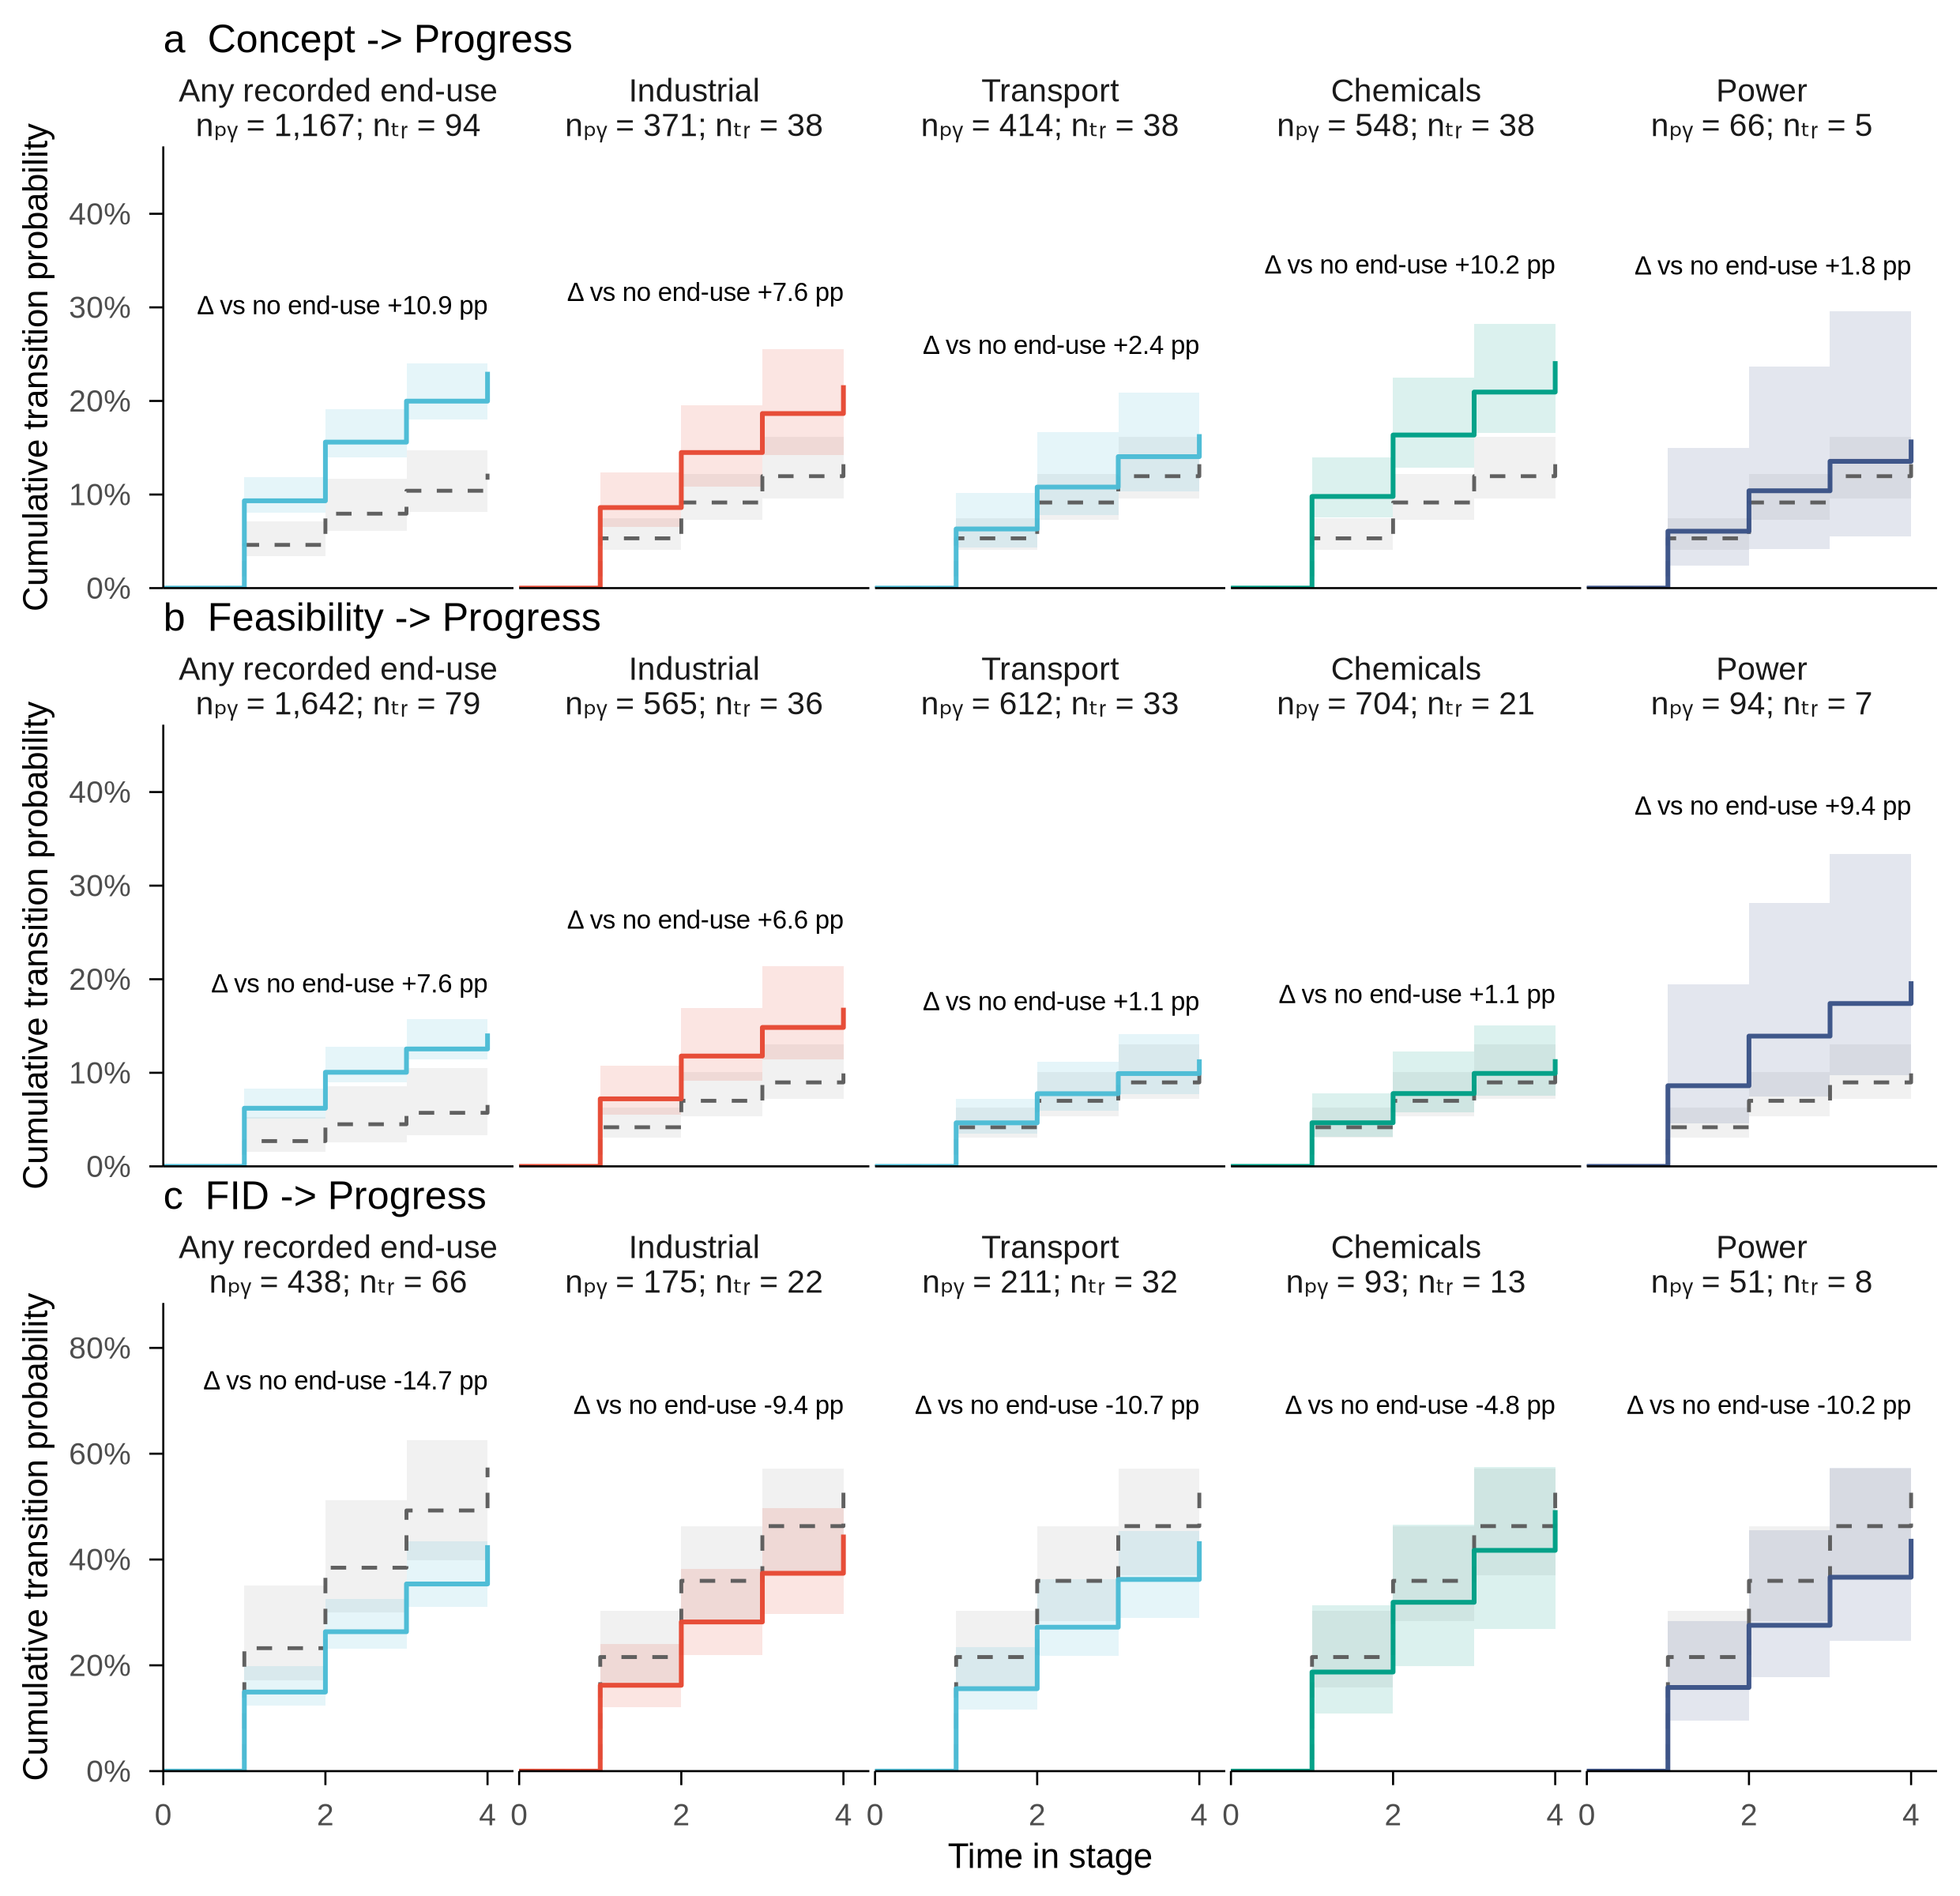

In [3]:
# ==============================================================================
# FIGURE 4:
# END-USE TRANSITION CURVES WITH OBSERVED TRANSITION COUNTS
#
# - five aligned facets per transition row
# - every facet compares the indicated end-use with no recorded end-use
# - the four sector facets share one common no-end-use reference curve
# - all five facets within a row use the same explicit y-axis limits
# - facet titles report observed transition events in the solid-line category
# ==============================================================================


# ------------------------------------------------------------------------------
# Figure settings
# ------------------------------------------------------------------------------

transition_panel_labels <- c(
  "Concept -> Progress" = "a",
  "Feasibility -> Progress" = "b",
  "FID -> Progress" = "c"
)

enduse_facet_order <- c(
  "Any recorded end-use",
  unname(
    enduse_labels[enduse_vars_plot]
  )
)

enduse_facet_colours <- c(
  "Any recorded end-use" =
    curve_cols_any[["At least one recorded end-use"]],
  curve_cols_grouped
)


# ------------------------------------------------------------------------------
# Plot style
# ------------------------------------------------------------------------------

base_theme <- theme_minimal(
  base_size = 12.75
) +
  theme(
    panel.grid = element_blank(),
    panel.border = element_blank(),

    axis.line.x.bottom = element_line(
      colour = "black",
      linewidth = 0.3
    ),

    axis.line.y.left = element_line(
      colour = "black",
      linewidth = 0.3
    ),

    axis.ticks.x = element_line(
      colour = "black",
      linewidth = 0.3
    ),

    axis.ticks.y = element_line(
      colour = "black",
      linewidth = 0.3
    ),

    axis.ticks.length = grid::unit(
      1.5,
      "mm"
    ),

    plot.title = element_text(
      hjust = 0,
      face = "plain",
      size = 14.25,
      margin = margin(
        b = 4
      )
    ),

    axis.text = element_text(
      size = 11.25
    ),

    axis.title = element_text(
      size = 12
    ),

    strip.text = element_text(
      size = 11.25,
      face = "plain",
      margin = margin(
        b = 2
      )
    ),

    plot.margin = margin(
      3,
      3,
      3,
      3
    )
  )


# ------------------------------------------------------------------------------
# Combine selected-group and no-end-use reference data for one row
# ------------------------------------------------------------------------------

make_transition_enduse_plot_data <- function(
    transition_name
) {
  transition_data <- demand_curve_data %>%
    dplyr::filter(
      transition == transition_name
    ) %>%
    dplyr::mutate(
      facet_label = factor(
        facet_label,
        levels = enduse_facet_order
      )
    )

  transition_counts <- transition_data %>%
    dplyr::filter(
      curve_type == "Selected group",
      time == 0
    ) %>%
    dplyr::distinct(
      facet_label,
      n_project_years,
      n_transitions
    ) %>%
    dplyr::arrange(
      facet_label
    ) %>%
    dplyr::mutate(
      facet_title = paste0(
        as.character(facet_label),
        "\nnₚᵧ = ",
        scales::comma(
          n_project_years,
          accuracy = 1
        ),
        "; nₜᵣ = ",
        scales::comma(
          n_transitions,
          accuracy = 1
        )
      )
    )

  facet_title_levels <- transition_counts$facet_title

  selected_data <- transition_data %>%
    dplyr::filter(
      curve_type == "Selected group"
    ) %>%
    dplyr::left_join(
      transition_counts,
      by = c(
        "facet_label",
        "n_project_years",
        "n_transitions"
      )
    ) %>%
    dplyr::mutate(
      facet_title = factor(
        facet_title,
        levels = facet_title_levels
      )
    )

  reference_data <- transition_data %>%
    dplyr::filter(
      curve_type == "No end-use reference"
    ) %>%
    dplyr::left_join(
      transition_counts,
      by = c(
        "facet_label",
        "n_project_years",
        "n_transitions"
      )
    ) %>%
    dplyr::mutate(
      facet_title = factor(
        facet_title,
        levels = facet_title_levels
      )
    )

  label_data <- make_demand_difference_labels(
    transition_data
  ) %>%
    dplyr::left_join(
      transition_counts,
      by = "facet_label"
    ) %>%
    dplyr::mutate(
      facet_title = factor(
        facet_title,
        levels = facet_title_levels
      )
    )

  selected_ribbon_data <- make_step_ribbon_data(
    data = selected_data,
    group_vars = c(
      "transition",
      "facet_label",
      "facet_title"
    )
  )

  reference_ribbon_data <- make_step_ribbon_data(
    data = reference_data,
    group_vars = c(
      "transition",
      "facet_label",
      "facet_title"
    )
  )

  list(
    selected_data = selected_data,
    reference_data = reference_data,
    label_data = label_data,
    selected_ribbon_data = selected_ribbon_data,
    reference_ribbon_data = reference_ribbon_data
  )
}

# ------------------------------------------------------------------------------
# Construct one transition row
# ------------------------------------------------------------------------------

make_transition_enduse_plot <- function(
    transition_name,
    panel_label,
    show_x_axis = FALSE
) {
  plot_data <- make_transition_enduse_plot_data(
    transition_name
  )


  # Use one explicit y-axis range across every facet in this transition row.
  row_y_values <- c(
    plot_data$selected_data$cumulative_transition_probability,
    plot_data$selected_data$conf_high,
    plot_data$reference_data$cumulative_transition_probability,
    plot_data$reference_data$conf_high,
    plot_data$label_data$label_y
  )

  row_y_values <- row_y_values[
    is.finite(row_y_values)
  ]

  row_y_upper <- if (length(row_y_values) == 0) {
    1
  } else {
    min(
      1,
      max(
        0.05,
        ceiling(
          (max(row_y_values) + 0.02) / 0.05
        ) * 0.05
      )
    )
  }

  row_y_limits <- c(
    0,
    row_y_upper
  )

  p <- ggplot() +
    geom_ribbon(
      data = plot_data$reference_ribbon_data,
      aes(
        x = time,
        ymin = conf_low,
        ymax = conf_high,
        group = facet_title
      ),
      fill = "grey70",
      alpha = 0.18,
      colour = NA,
      show.legend = FALSE
    ) +

    geom_ribbon(
      data = plot_data$selected_ribbon_data,
      aes(
        x = time,
        ymin = conf_low,
        ymax = conf_high,
        fill = facet_label,
        group = facet_title
      ),
      alpha = 0.14,
      colour = NA,
      show.legend = FALSE
    ) +

    geom_step(
      data = plot_data$reference_data,
      aes(
        x = time,
        y = cumulative_transition_probability,
        group = facet_title
      ),
      colour = "grey35",
      linewidth = 0.55,
      alpha = 0.95,
      linetype = "dashed",
      direction = "hv",
      show.legend = FALSE
    ) +

    geom_step(
      data = plot_data$selected_data,
      aes(
        x = time,
        y = cumulative_transition_probability,
        colour = facet_label,
        group = facet_title
      ),
      linewidth = 0.68,
      alpha = 0.98,
      direction = "hv",
      show.legend = FALSE
    ) +

    geom_text(
      data = plot_data$label_data,
      aes(
        x = time,
        y = label_y,
        label = label
      ),
      inherit.aes = FALSE,
      hjust = 1,
      vjust = -0.25,
      size = 2.775,
      colour = "black"
    ) +

    facet_wrap(
      ~ facet_title,
      nrow = 1,
      scales = "fixed"
    ) +

    scale_colour_manual(
      values = enduse_facet_colours,
      breaks = enduse_facet_order,
      drop = FALSE
    ) +

    scale_fill_manual(
      values = enduse_facet_colours,
      breaks = enduse_facet_order,
      drop = FALSE
    ) +

    scale_x_continuous(
      breaks = scales::breaks_pretty(
        n = 3
      ),
      limits = c(
        0,
        NA
      ),
      expand = expansion(
        mult = c(
          0,
          0.08
        )
      )
    ) +

    scale_y_continuous(
      limits = row_y_limits,
      labels = scales::label_percent(
        accuracy = 1
      ),
      breaks = scales::breaks_pretty(
        n = 4
      ),
      expand = expansion(
        mult = c(
          0,
          0.18
        )
      )
    ) +

    labs(
      title = paste0(
        panel_label,
        "  ",
        transition_name
      ),
      x = if (show_x_axis) {
        "Time in stage"
      } else {
        NULL
      },
      y = "Cumulative transition probability"
    ) +

    base_theme +

    theme(
      legend.position = "none",

      plot.title = element_text(
        hjust = 0,
        size = 12,
        face = "plain",
        margin = margin(
          b = 2
        )
      ),

      axis.title.x = element_text(
        size = 10.5,
        margin = margin(
          t = 3
        )
      ),

      axis.title.y = element_text(
        size = 10.5,
        margin = margin(
          r = 3
        )
      ),

      axis.text.x = element_text(
        size = 9.3
      ),

      axis.text.y = element_text(
        size = 9.3
      ),

      strip.text = element_text(
        size = 9.75,
        margin = margin(
          t = 2,
          b = 2
        )
      ),

      panel.spacing.x = grid::unit(
        0.12,
        "lines"
      ),

      plot.margin = margin(
        2,
        2,
        2,
        2
      )
    )

  if (!show_x_axis) {
    p <- p +
      theme(
        axis.text.x = element_blank(),
        axis.ticks.x = element_blank()
      )
  }

  p
}


# ------------------------------------------------------------------------------
# Construct transition rows
# ------------------------------------------------------------------------------

p_concept_enduse <- make_transition_enduse_plot(
  transition_name = "Concept -> Progress",
  panel_label = transition_panel_labels[["Concept -> Progress"]],
  show_x_axis = FALSE
)


p_feasibility_enduse <- make_transition_enduse_plot(
  transition_name = "Feasibility -> Progress",
  panel_label = transition_panel_labels[["Feasibility -> Progress"]],
  show_x_axis = FALSE
)


p_fid_enduse <- make_transition_enduse_plot(
  transition_name = "FID -> Progress",
  panel_label = transition_panel_labels[["FID -> Progress"]],
  show_x_axis = TRUE
)


# ------------------------------------------------------------------------------
# A4 portrait composition
# ------------------------------------------------------------------------------

p_figure4_enduse <-
  (
    p_concept_enduse /
      p_feasibility_enduse /
      p_fid_enduse
  ) +
  patchwork::plot_layout(
    heights = c(
      1,
      1,
      1.06
    )
  ) +
  patchwork::plot_annotation(
    theme = theme(
      plot.margin = margin(
        5,
        5,
        5,
        5
      )
    )
  )


# ------------------------------------------------------------------------------
# Render and export
# ------------------------------------------------------------------------------

figure_width_in <- 8.27
figure_height_in <- 8

options(
  repr.plot.width = figure_width_in,
  repr.plot.height = figure_height_in,
  repr.plot.res = 300
)

print(
  p_figure4_enduse
)


ggsave(
  filename = "figure_demand.pdf",
  plot = p_figure4_enduse,
  width = figure_width_in,
  height = figure_height_in,
  units = "in",
  device = cairo_pdf
)


## Supplementary Figure S3: Competing risk model Demand

These panels use the fitted discrete-time multinomial competing-risk model and show the cumulative incidence of progression while retaining failure as a competing event. At each duration, `No transition`, `Progress` and `Failure` are estimated jointly and sum to one by construction. The cumulative progression incidence is propagated recursively through the probability of remaining event-free. Simulation-based 90% confidence bands use the project-clustered multinomial covariance matrix.

Output: `figure_S3_competing_risk_demand.pdf` and matching source-data CSV. This section loads the saved multinomial models and does not re-estimate the primary cloglog models.


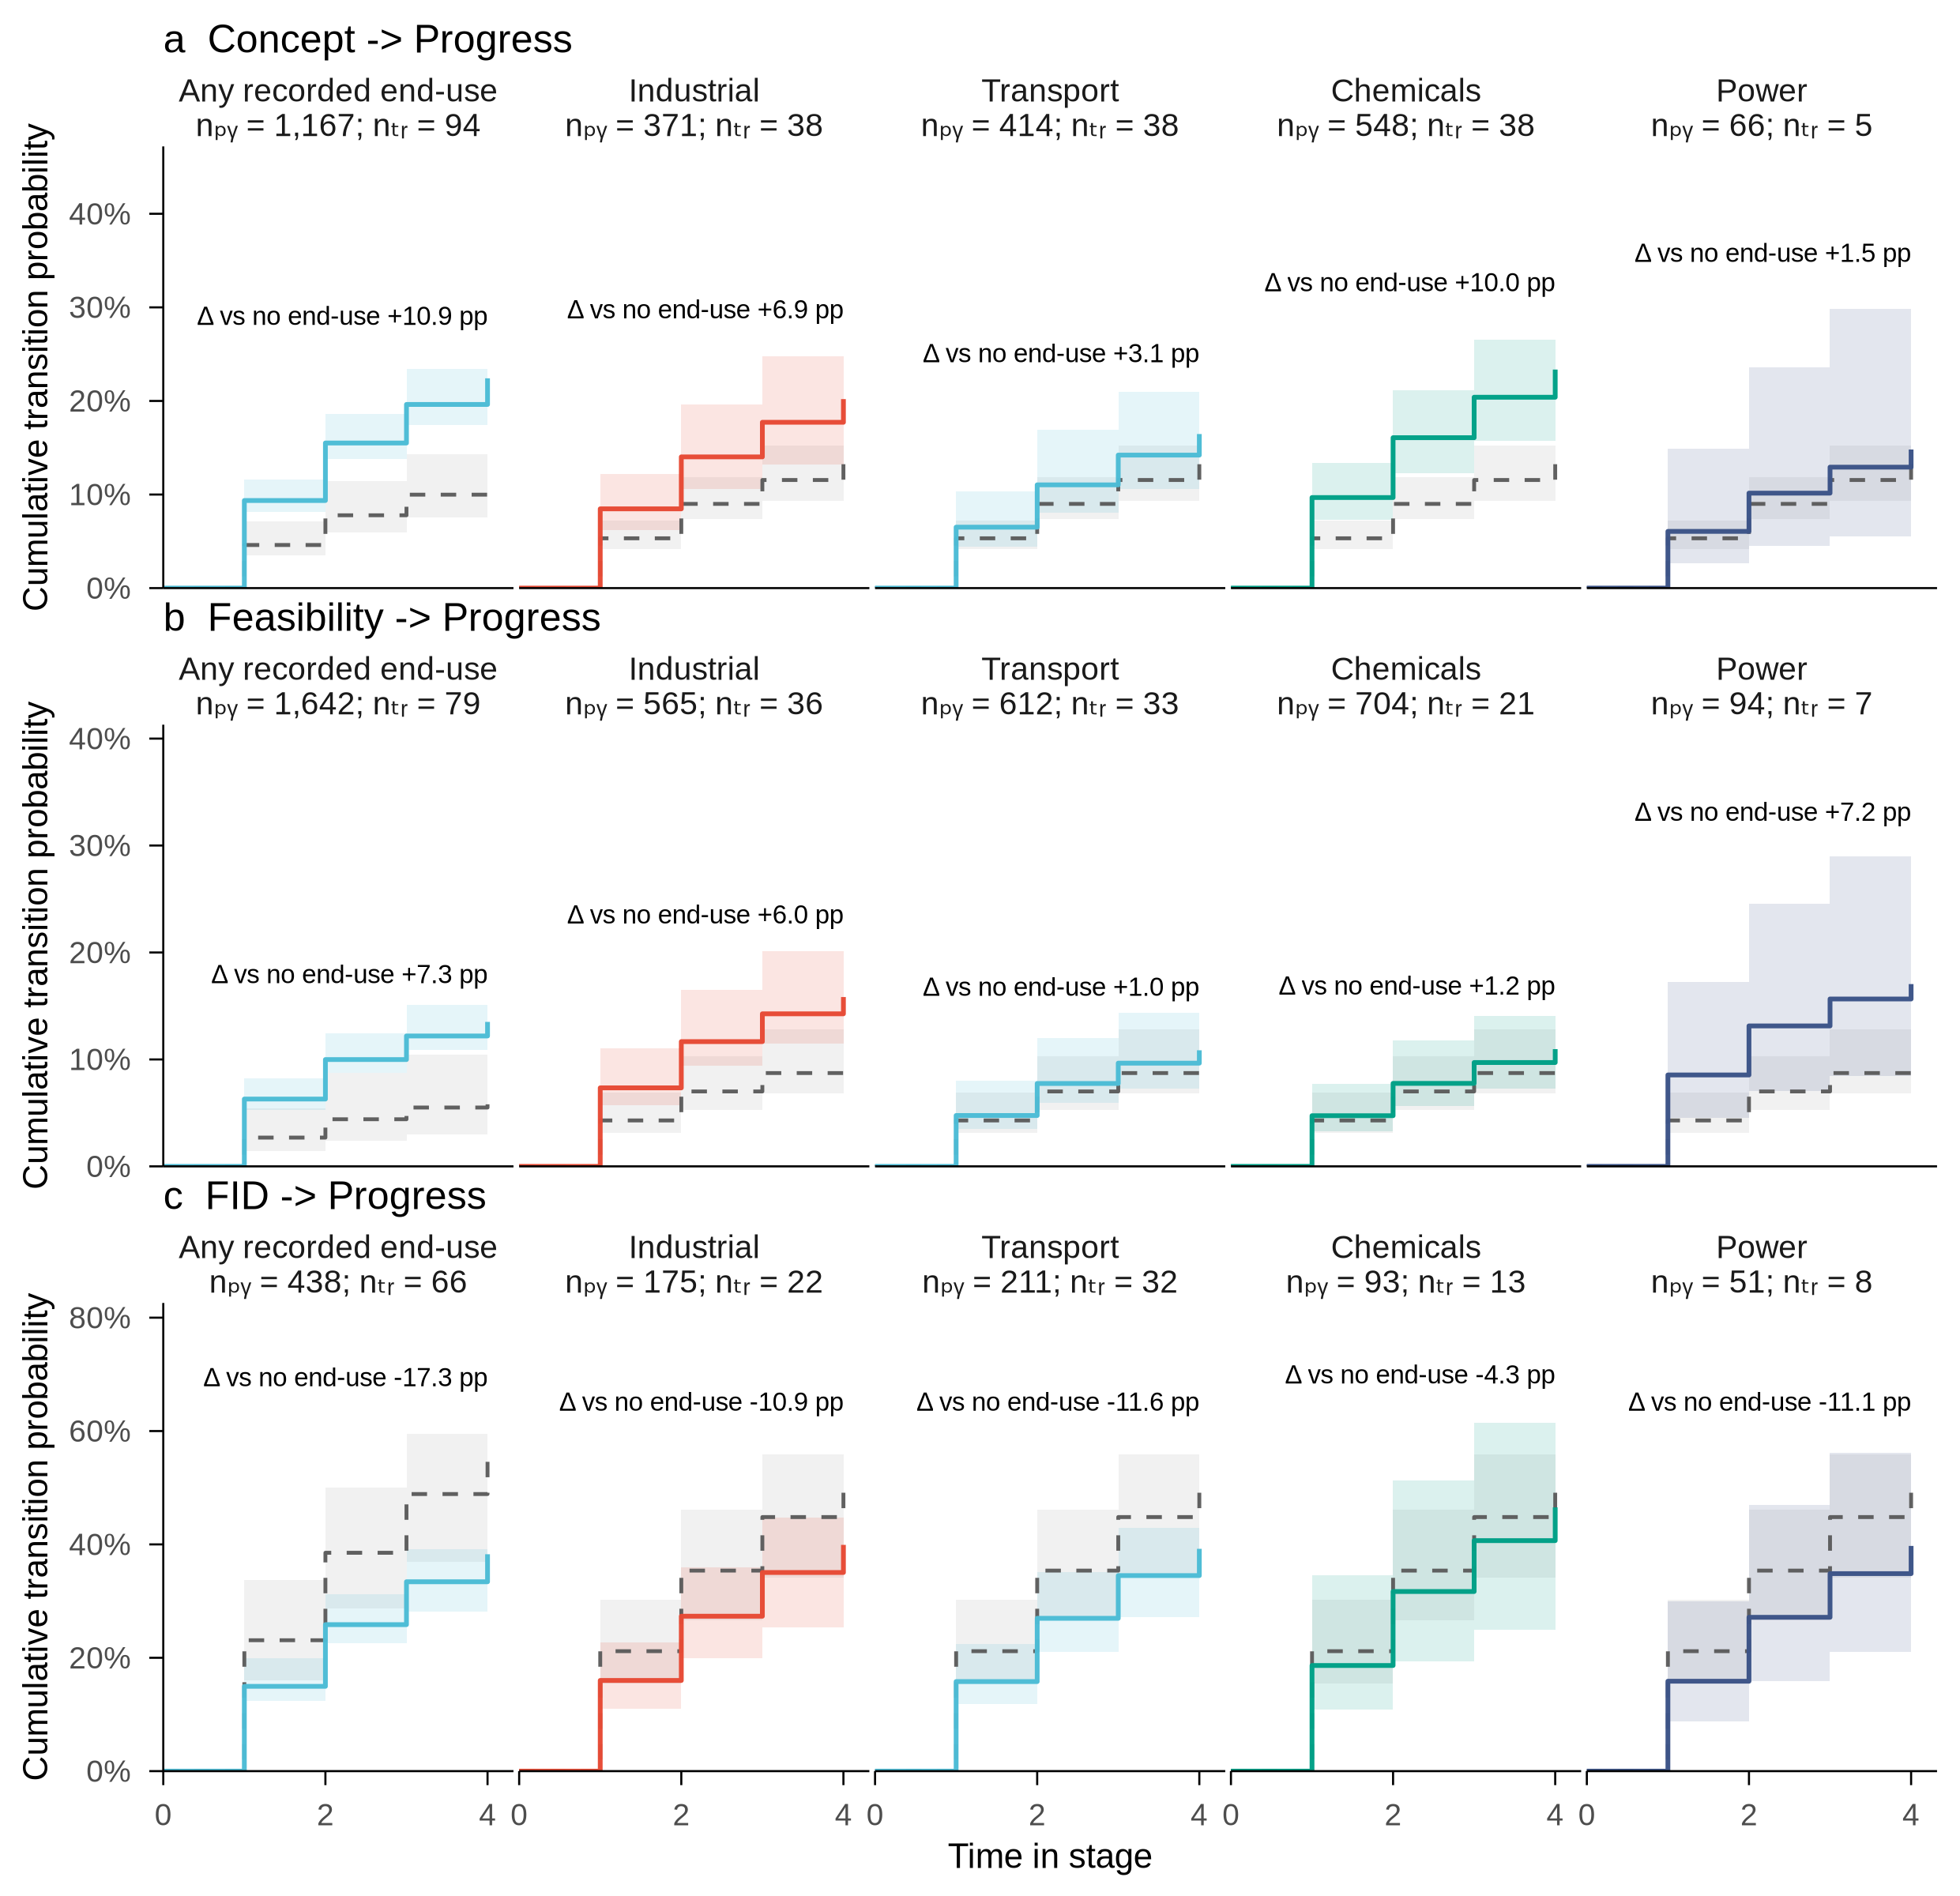

In [4]:
# ==============================================================================
# Packages and multinomial competing-risk inputs
# ==============================================================================

required_packages <- c(
  "dplyr",
  "tidyr",
  "purrr",
  "sandwich",
  "ggplot2",
  "ggsci",
  "scales",
  "patchwork",
  "nnet",
  "MASS"
)

missing_packages <- required_packages[
  !vapply(
    required_packages,
    requireNamespace,
    logical(1),
    quietly = TRUE
  )
]

if (length(missing_packages) > 0) {
  stop(
    paste0(
      "Missing packages: ",
      paste(missing_packages, collapse = ", "),
      ". Install them before running this notebook."
    )
  )
}

invisible(
  lapply(
    required_packages,
    library,
    character.only = TRUE
  )
)

set.seed(123)


# ------------------------------------------------------------------------------
# Load the shared competing-risk data
# ------------------------------------------------------------------------------

data_file <- "cloglog_data_processed.rds"

if (!file.exists(data_file)) {
  stop(
    paste0(
      "The competing-risk data file '",
      data_file,
      "' was not found. Run Data Preparation before this notebook."
    )
  )
}

cloglog_data <- readRDS(data_file)

# ------------------------------------------------------------------------------
# Load the fitted multinomial competing-risk models
# ------------------------------------------------------------------------------

model_results_file <- "multinomial_competing_risk_results.rds"

if (!file.exists(model_results_file)) {
  stop(
    paste0(
      "The multinomial competing-risk model-results file '",
      model_results_file,
      "' was not found. Run Discrete-Time-Multinomial-Competing-Risk-Model.ipynb before constructing these figures."
    )
  )
}

joint_competing_results <- readRDS(model_results_file)
assert_joint_model_variables <- function(model, required, context) {
  variables <- all.vars(stats::delete.response(stats::terms(model)))
  missing <- setdiff(required, variables)
  if (length(missing) > 0L) {
    stop(paste0(context, " is missing required multinomial-model predictors: ",
                paste(missing, collapse = ", ")))
  }
  invisible(TRUE)
}


transition_names <- c(
  "Concept -> Progress",
  "Feasibility -> Progress",
  "FID -> Progress"
)

grouped_model_name <- "Core + macro controls + year FE"
any_enduse_model_name <- "Core + macro controls + year FE + any enduse"

extract_joint_models <- function(
    results,
    transitions,
    model_name
) {
  extracted_models <- lapply(
    transitions,
    function(transition_name) {
      transition_models <- results$models[[transition_name]]

      if (is.null(transition_models)) {
        stop(
          paste0(
            "Transition '",
            transition_name,
            "' was not found in ",
            model_results_file,
            "."
          )
        )
      }

      model_obj <- transition_models[[model_name]]

      if (is.null(model_obj) || is.null(model_obj$model)) {
        stop(
          paste0(
            "Model '",
            model_name,
            "' was not available for ",
            transition_name,
            "."
          )
        )
      }

      model_obj
    }
  )

  names(extracted_models) <- transitions

  list(
    models = extracted_models
  )
}

joint_results_grouped_full <- extract_joint_models(
  results = joint_competing_results,
  transitions = transition_names,
  model_name = grouped_model_name
)

joint_results_any_full <- extract_joint_models(
  results = joint_competing_results,
  transitions = transition_names,
  model_name = any_enduse_model_name
)


# ------------------------------------------------------------------------------
# Figure settings and plotted end-use indicators
# ------------------------------------------------------------------------------

time_var <- "prev_time_in_status"
raw_time_var <- "prev_time_in_status_raw"
n_draws <- 300
conf_level <- 0.90

enduse_vars_model <- c(
  "enduse_industrial",
  "enduse_transport",
  "enduse_chemicals",
  "enduse_power",
  "enduse_other"
)

grouped_model_terms <- unique(
  unlist(
    lapply(
      joint_results_grouped_full$models,
      function(model_obj) {
        all.vars(stats::delete.response(stats::terms(model_obj$model)))
      }
    ),
    use.names = FALSE
  )
)

enduse_vars_model <- enduse_vars_model[
  enduse_vars_model %in% grouped_model_terms
]

if (length(enduse_vars_model) == 0) {
  stop(
    "The multinomial competing-risk grouped-end-use model contains no plotted end-use indicators."
  )
}


enduse_vars_plot <- setdiff(
  enduse_vars_model,
  "enduse_other"
)

enduse_labels <- c(
  enduse_industrial = "Industrial",
  enduse_transport = "Transport",
  enduse_chemicals = "Chemicals",
  enduse_power = "Power",
  enduse_other = "Other"
)

curve_levels_any <- c(
  "No recorded end-use",
  "At least one recorded end-use"
)

curve_levels_grouped <- unname(
  enduse_labels[enduse_vars_plot]
)

curve_cols_any <- ggsci::pal_npg()(length(curve_levels_any))
names(curve_cols_any) <- curve_levels_any

curve_cols_grouped <- ggsci::pal_npg()(length(curve_levels_grouped))
names(curve_cols_grouped) <- curve_levels_grouped

base_theme <- theme_minimal(base_size = 12.75) +
  theme(
    panel.grid = element_blank(),
    panel.border = element_blank(),
    axis.line.x.bottom = element_line(colour = "black", linewidth = 0.3),
    axis.line.y.left = element_line(colour = "black", linewidth = 0.3),
    axis.ticks.x = element_line(colour = "black", linewidth = 0.3),
    axis.ticks.y = element_line(colour = "black", linewidth = 0.3),
    axis.ticks.length = unit(1.5, "mm"),
    plot.title = element_text(
      hjust = 0,
      face = "plain",
      size = 14.25,
      margin = margin(b = 4)
    ),
    axis.text = element_text(size = 12),
    axis.title = element_text(size = 12.75),
    legend.title = element_text(size = 12.75),
    legend.text = element_text(size = 12),
    legend.key.size = unit(0.42, "cm"),
    legend.spacing.y = unit(0.08, "cm"),
    legend.margin = margin(0, 0, 0, 0),
    plot.margin = margin(6, 6, 6, 6)
  )

make_psd <- function(x) {
  x <- (x + t(x)) / 2
  x[!is.finite(x)] <- 0

  eig <- eigen(x, symmetric = TRUE)
  eig$values <- pmax(eig$values, .Machine$double.eps)

  eig$vectors %*%
    diag(eig$values, nrow = length(eig$values)) %*%
    t(eig$vectors)
}

make_coef_draws <- function(
    model,
    model_data,
    n_draws = 300
) {
  beta_hat <- model$multinomial_coef_vector
  vcov_mat <- model$cluster_vcov

  if (is.null(beta_hat) || is.null(vcov_mat)) {
    stop("The saved multinomial model does not contain clustered inference objects.")
  }

  if (any(!is.finite(beta_hat)) ||
      any(!is.finite(vcov_mat)) ||
      any(diag(vcov_mat) < 0)) {
    stop("The multinomial coefficient vector or clustered covariance is non-finite.")
  }

  draws <- MASS::mvrnorm(
    n = n_draws,
    mu = beta_hat,
    Sigma = make_psd(vcov_mat)
  )

  draws <- as.matrix(draws)
  colnames(draws) <- names(beta_hat)
  draws
}

make_multinomial_prediction_matrix <- function(model, pred_data) {
  terms_no_response <- stats::delete.response(stats::terms(model))

  model_frame <- stats::model.frame(
    terms_no_response,
    data = pred_data,
    xlev = model$xlevels,
    na.action = stats::na.pass,
    drop.unused.levels = FALSE
  )

  x_mat <- stats::model.matrix(
    terms_no_response,
    data = model_frame,
    contrasts.arg = model$contrasts
  )

  target_terms <- colnames(model$multinomial_coef_matrix)
  missing_terms <- setdiff(target_terms, colnames(x_mat))

  if (length(missing_terms) > 0) {
    missing_mat <- matrix(
      0,
      nrow = nrow(x_mat),
      ncol = length(missing_terms)
    )
    colnames(missing_mat) <- missing_terms
    x_mat <- cbind(x_mat, missing_mat)
  }

  x_mat[, target_terms, drop = FALSE]
}

stable_multinomial_probabilities <- function(eta_progress, eta_failure) {
  max_eta <- pmax(0, eta_progress, eta_failure)
  denominator <- exp(-max_eta) +
    exp(eta_progress - max_eta) +
    exp(eta_failure - max_eta)

  list(
    no_transition = exp(-max_eta) / denominator,
    progress = exp(eta_progress - max_eta) / denominator,
    failure = exp(eta_failure - max_eta) / denominator
  )
}

predict_multinomial_competing_draws <- function(
    model,
    pred_data,
    coef_draws
) {
  x_mat <- make_multinomial_prediction_matrix(model, pred_data)
  coef_matrix <- model$multinomial_coef_matrix

  required_classes <- c("Progress", "Failure")
  if (!all(required_classes %in% rownames(coef_matrix))) {
    stop("The multinomial model is missing Progress or Failure coefficients.")
  }

  eta_progress_hat <- drop(x_mat %*% coef_matrix["Progress", ])
  eta_failure_hat <- drop(x_mat %*% coef_matrix["Failure", ])

  point_probs <- stable_multinomial_probabilities(
    eta_progress_hat,
    eta_failure_hat
  )

  progress_names <- paste0("Progress::", colnames(coef_matrix))
  failure_names <- paste0("Failure::", colnames(coef_matrix))

  if (!all(c(progress_names, failure_names) %in% colnames(coef_draws))) {
    stop("The coefficient draws do not align with the multinomial design matrix.")
  }

  eta_progress_draws <- x_mat %*%
    t(coef_draws[, progress_names, drop = FALSE])
  eta_failure_draws <- x_mat %*%
    t(coef_draws[, failure_names, drop = FALSE])

  draw_probs <- stable_multinomial_probabilities(
    eta_progress_draws,
    eta_failure_draws
  )

  list(
    no_transition_hat = as.numeric(point_probs$no_transition),
    progress_hat = as.numeric(point_probs$progress),
    failure_hat = as.numeric(point_probs$failure),
    no_transition_draws = as.matrix(draw_probs$no_transition),
    progress_draws = as.matrix(draw_probs$progress),
    failure_draws = as.matrix(draw_probs$failure)
  )
}

make_standardised_multinomial_curve <- function(
    model,
    pred_base,
    time_grid,
    time_scale,
    coef_draws,
    time_var = "prev_time_in_status",
    raw_time_var = "prev_time_in_status_raw",
    conf_level = 0.90
) {
  if (nrow(pred_base) == 0) {
    return(NULL)
  }

  alpha <- 1 - conf_level
  number_of_draws <- nrow(coef_draws)

  survival_hat <- rep(1, nrow(pred_base))
  progression_cif_hat <- rep(0, nrow(pred_base))

  survival_draws <- matrix(
    1,
    nrow = nrow(pred_base),
    ncol = number_of_draws
  )
  progression_cif_draws <- matrix(
    0,
    nrow = nrow(pred_base),
    ncol = number_of_draws
  )

  annual_hazard <- numeric(length(time_grid))
  cumulative_hat <- numeric(length(time_grid))
  cumulative_draw_mat <- matrix(
    NA_real_,
    nrow = length(time_grid),
    ncol = number_of_draws
  )

  for (i in seq_along(time_grid)) {
    pred_data <- pred_base
    pred_data[[raw_time_var]] <- time_grid[i]
    pred_data[[time_var]] <- apply_time_scale(
      time_raw = time_grid[i],
      time_scale = time_scale
    )

    pred <- predict_multinomial_competing_draws(
      model = model,
      pred_data = pred_data,
      coef_draws = coef_draws
    )

    point_sum <- pred$no_transition_hat +
      pred$progress_hat +
      pred$failure_hat

    if (any(!is.finite(point_sum)) ||
        any(abs(point_sum - 1) > 1e-8)) {
      stop(
        paste0(
          "Multinomial outcome probabilities are not coherent at duration ",
          time_grid[i],
          "."
        )
      )
    }

    progression_cif_hat <- progression_cif_hat +
      survival_hat * pred$progress_hat
    survival_hat <- survival_hat * pred$no_transition_hat

    progression_cif_draws <- progression_cif_draws +
      survival_draws * pred$progress_draws
    survival_draws <- survival_draws * pred$no_transition_draws

    annual_hazard[i] <- mean(pred$progress_hat, na.rm = TRUE)
    cumulative_hat[i] <- mean(progression_cif_hat, na.rm = TRUE)
    cumulative_draw_mat[i, ] <- colMeans(
      progression_cif_draws,
      na.rm = TRUE
    )
  }

  ci_mat <- t(
    apply(
      cumulative_draw_mat,
      1,
      stats::quantile,
      probs = c(alpha / 2, 1 - alpha / 2),
      na.rm = TRUE
    )
  )

  dplyr::bind_rows(
    tibble::tibble(
      time = 0,
      annual_hazard = NA_real_,
      cumulative_transition_probability = 0,
      conf_low = 0,
      conf_high = 0,
      valid_multinomial_draws = number_of_draws
    ),
    tibble::tibble(
      time = time_grid,
      annual_hazard = annual_hazard,
      cumulative_transition_probability = cumulative_hat,
      conf_low = ci_mat[, 1],
      conf_high = ci_mat[, 2],
      valid_multinomial_draws = number_of_draws
    )
  )
}


make_time_grid <- function(
    model_data,
    time_var,
    raw_time_var = "prev_time_in_status_raw"
) {
  if (!all(c(time_var, raw_time_var) %in% names(model_data))) {
    stop(
      paste0(
        "The fitted model data must contain both '",
        time_var,
        "' and '",
        raw_time_var,
        "'. Re-run Data Preparation and multinomial competing-risk."
      )
    )
  }

  max_time <- max(
    model_data[[raw_time_var]],
    na.rm = TRUE
  )

  if (!is.finite(max_time) || max_time < 1) {
    return(NULL)
  }

  seq(
    from = 1,
    to = ceiling(max_time),
    by = 1
  )
}

get_time_scale <- function(
    model_data,
    time_var,
    raw_time_var = "prev_time_in_status_raw"
) {
  time_mapping <- model_data %>%
    dplyr::transmute(
      time_model = as.numeric(.data[[time_var]]),
      time_raw = as.numeric(.data[[raw_time_var]])
    ) %>%
    dplyr::filter(
      is.finite(time_model),
      is.finite(time_raw)
    ) %>%
    dplyr::distinct()

  if (dplyr::n_distinct(time_mapping$time_raw) < 2) {
    stop("At least two raw duration values are required to recover the model scale.")
  }

  mapping_model <- stats::lm(
    time_model ~ time_raw,
    data = time_mapping
  )

  c(
    intercept = unname(stats::coef(mapping_model)[[1]]),
    slope = unname(stats::coef(mapping_model)[[2]])
  )
}

apply_time_scale <- function(
    time_raw,
    time_scale
) {
  unname(
    time_scale[["intercept"]] +
      time_scale[["slope"]] * time_raw
  )
}

make_target_time_grid <- function(
    model_data,
    time_var,
    target_enduse,
    raw_time_var = "prev_time_in_status_raw"
) {
  target_data <- model_data %>%
    dplyr::filter(
      !is.na(.data[[target_enduse]]),
      .data[[target_enduse]] == 1
    )

  make_time_grid(
    model_data = target_data,
    time_var = time_var,
    raw_time_var = raw_time_var
  )
}

make_step_ribbon_data <- function(data, group_vars) {
  
  if (nrow(data) == 0) {
    return(data)
  }
  
  value_cols <- c(
    "annual_hazard",
    "cumulative_transition_probability",
    "conf_low",
    "conf_high"
  )
  
  data %>%
    dplyr::arrange(dplyr::across(dplyr::all_of(c(group_vars, "time")))) %>%
    dplyr::group_by(dplyr::across(dplyr::all_of(group_vars))) %>%
    dplyr::group_modify(function(.x, .y) {
      
      .x <- .x %>%
        dplyr::arrange(time)
      
      if (nrow(.x) <= 1) {
        return(.x)
      }
      
      out <- .x[1, , drop = FALSE]
      
      for (i in 2:nrow(.x)) {
        previous_row <- .x[i - 1, , drop = FALSE]
        current_row <- .x[i, , drop = FALSE]
        
        step_row <- current_row
        step_row[value_cols] <- previous_row[value_cols]
        
        out <- dplyr::bind_rows(
          out,
          step_row,
          current_row
        )
      }
      
      out
    }) %>%
    dplyr::ungroup()
}

# ------------------------------------------------------------------------------
# Generate end-use versus no-end-use transition curves
#
# The left facet uses the separate any-end-use model and compares predictions
# with any_enduse fixed to 1 versus 0 across the same estimation sample.
#
# The four sector facets use the grouped end-use model. For each solid curve,
# the indicated end-use is fixed to 1 and all other end-use indicators are fixed
# to 0. The dashed reference fixes every end-use indicator to 0. This common
# no-end-use reference is repeated across all four sector facets.
# ------------------------------------------------------------------------------

make_any_enduse_curve_data <- function(
    cloglog_results,
    transition_name,
    time_var = "prev_time_in_status",
    n_draws = 300,
    conf_level = 0.90
) {
  model_obj <- cloglog_results$models[[transition_name]]

  if (is.null(model_obj)) {
    return(NULL)
  }

  model <- model_obj$model
  model_data <- model_obj$data
  outcome <- "progress"  # Unstacked project-year outcome; joint_event is stacked.

  model_terms <- all.vars(stats::delete.response(stats::terms(model)))

  assert_joint_model_variables(model, c(time_var, "any_enduse"), transition_name)

  if (!time_var %in% names(model_data)) {
    return(NULL)
  }

  time_grid <- make_time_grid(
    model_data = model_data,
    time_var = time_var
  )

  if (is.null(time_grid)) {
    return(NULL)
  }

  time_scale <- get_time_scale(
    model_data = model_data,
    time_var = time_var,
    raw_time_var = raw_time_var
  )

  coef_draws <- make_coef_draws(
    model = model,
    model_data = model_data,
    n_draws = n_draws
  )

  number_of_draws <- nrow(coef_draws)

  make_curve <- function(any_enduse_value) {
    pred_base <- model_data
    pred_base$any_enduse <- any_enduse_value

    make_standardised_multinomial_curve(
      model = model,
      pred_base = pred_base,
      time_grid = time_grid,
      time_scale = time_scale,
      coef_draws = coef_draws,
      time_var = time_var,
      raw_time_var = raw_time_var,
      conf_level = conf_level
    )
  }

  n_project_years <- sum(
    model_data$any_enduse == 1,
    na.rm = TRUE
  )

  n_transitions <- sum(
    model_data[[outcome]] == 1 & model_data$any_enduse == 1,
    na.rm = TRUE
  )

  selected_curve <- make_curve(
    any_enduse_value = 1
  ) %>%
    dplyr::mutate(
      transition = transition_name,
      facet_label = "Any recorded end-use",
      target_enduse = "any_enduse",
      curve_type = "Selected group",
      reference_label = "No recorded end-use",
      n_project_years = n_project_years,
      n_transitions = n_transitions
    )

  reference_curve <- make_curve(
    any_enduse_value = 0
  ) %>%
    dplyr::mutate(
      transition = transition_name,
      facet_label = "Any recorded end-use",
      target_enduse = "any_enduse",
      curve_type = "No end-use reference",
      reference_label = "No recorded end-use",
      n_project_years = n_project_years,
      n_transitions = n_transitions
    )

  dplyr::bind_rows(
    selected_curve,
    reference_curve
  )
}

make_grouped_enduse_curve_data <- function(
    cloglog_results,
    transition_name,
    enduse_vars,
    all_enduse_vars,
    time_var = "prev_time_in_status",
    enduse_labels = NULL,
    n_draws = 300,
    conf_level = 0.90
) {
  model_obj <- cloglog_results$models[[transition_name]]

  if (is.null(model_obj)) {
    return(NULL)
  }

  model <- model_obj$model
  model_data <- model_obj$data
  outcome <- "progress"  # Unstacked project-year outcome; joint_event is stacked.

  model_terms <- all.vars(stats::delete.response(stats::terms(model)))

  assert_joint_model_variables(model, c(time_var, all_enduse_vars), transition_name)

  model_enduse_vars <- all_enduse_vars[
    all_enduse_vars %in% names(model_data) &
      all_enduse_vars %in% model_terms
  ]

  enduse_vars <- enduse_vars[
    enduse_vars %in% model_enduse_vars
  ]

  if (length(enduse_vars) == 0 || length(model_enduse_vars) == 0) {
    return(NULL)
  }

  if (!time_var %in% names(model_data)) {
    return(NULL)
  }

  time_grid <- make_time_grid(
    model_data = model_data,
    time_var = time_var
  )

  if (is.null(time_grid)) {
    return(NULL)
  }

  time_scale <- get_time_scale(
    model_data = model_data,
    time_var = time_var,
    raw_time_var = raw_time_var
  )

  coef_draws <- make_coef_draws(
    model = model,
    model_data = model_data,
    n_draws = n_draws
  )

  number_of_draws <- nrow(coef_draws)

  make_curve <- function(pred_base) {
    make_standardised_multinomial_curve(
      model = model,
      pred_base = pred_base,
      time_grid = time_grid,
      time_scale = time_scale,
      coef_draws = coef_draws,
      time_var = time_var,
      raw_time_var = raw_time_var,
      conf_level = conf_level
    )
  }

  no_enduse_base <- model_data

  for (enduse_var in model_enduse_vars) {
    no_enduse_base[[enduse_var]] <- 0
  }

  no_enduse_curve <- make_curve(
    pred_base = no_enduse_base
  )

  purrr::map_dfr(
    enduse_vars,
    function(target_enduse) {
      facet_label <- if (
        !is.null(enduse_labels) &&
          target_enduse %in% names(enduse_labels)
      ) {
        unname(enduse_labels[[target_enduse]])
      } else {
        target_enduse
      }

      observed_selector <- as.numeric(
        model_data[[target_enduse]]
      ) == 1

      n_project_years <- sum(
        observed_selector %in% TRUE,
        na.rm = TRUE
      )

      n_transitions <- sum(
        model_data[[outcome]] == 1 & observed_selector %in% TRUE,
        na.rm = TRUE
      )

      selected_base <- no_enduse_base
      selected_base[[target_enduse]] <- 1

      selected_curve <- make_curve(
        pred_base = selected_base
      ) %>%
        dplyr::mutate(
          transition = transition_name,
          facet_label = facet_label,
          target_enduse = target_enduse,
          curve_type = "Selected group",
          reference_label = "No recorded end-use",
          n_project_years = n_project_years,
          n_transitions = n_transitions
        )

      reference_curve <- no_enduse_curve %>%
        dplyr::mutate(
          transition = transition_name,
          facet_label = facet_label,
          target_enduse = target_enduse,
          curve_type = "No end-use reference",
          reference_label = "No recorded end-use",
          n_project_years = n_project_years,
          n_transitions = n_transitions
        )

      dplyr::bind_rows(
        selected_curve,
        reference_curve
      )
    }
  )
}

any_curve_data <- purrr::map_dfr(
  transition_names,
  ~ make_any_enduse_curve_data(
    cloglog_results = joint_results_any_full,
    transition_name = .x,
    time_var = time_var,
    n_draws = n_draws,
    conf_level = conf_level
  )
)

grouped_curve_data <- purrr::map_dfr(
  transition_names,
  ~ make_grouped_enduse_curve_data(
    cloglog_results = joint_results_grouped_full,
    transition_name = .x,
    enduse_vars = enduse_vars_plot,
    all_enduse_vars = enduse_vars_model,
    time_var = time_var,
    enduse_labels = enduse_labels,
    n_draws = n_draws,
    conf_level = conf_level
  )
)

demand_curve_data <- dplyr::bind_rows(
  any_curve_data,
  grouped_curve_data
) %>%
  dplyr::mutate(
    facet_label = factor(
      facet_label,
      levels = c(
        "Any recorded end-use",
        unname(enduse_labels[enduse_vars_plot])
      )
    )
  )

if (nrow(demand_curve_data) == 0) {
  stop("No end-use transition curves could be constructed.")
}

make_demand_difference_labels <- function(data) {
  selected_data <- data %>%
    dplyr::filter(curve_type == "Selected group") %>%
    dplyr::group_by(facet_label, target_enduse) %>%
    dplyr::slice_max(time, n = 1, with_ties = FALSE) %>%
    dplyr::ungroup() %>%
    dplyr::select(
      facet_label,
      target_enduse,
      time,
      selected_probability = cumulative_transition_probability,
      selected_conf_high = conf_high
    )

  reference_data <- data %>%
    dplyr::filter(curve_type == "No end-use reference") %>%
    dplyr::group_by(facet_label, target_enduse) %>%
    dplyr::slice_max(time, n = 1, with_ties = FALSE) %>%
    dplyr::ungroup() %>%
    dplyr::select(
      facet_label,
      target_enduse,
      reference_label,
      reference_probability = cumulative_transition_probability,
      reference_conf_high = conf_high
    )

  selected_data %>%
    dplyr::left_join(
      reference_data,
      by = c(
        "facet_label",
        "target_enduse"
      )
    ) %>%
    dplyr::mutate(
      difference_pp = 100 * (
        selected_probability - reference_probability
      ),
      label = paste0(
        "Δ vs no end-use ",
        sprintf("%+.1f", difference_pp),
        " pp"
      ),
      label_y = pmax(
        selected_probability,
        reference_probability,
        selected_conf_high,
        reference_conf_high,
        na.rm = TRUE
      )
    )
}


# ==============================================================================
# SUPPLEMENTARY COMPETING-RISK END-USE FIGURE:
# END-USE TRANSITION CURVES WITH OBSERVED TRANSITION COUNTS
#
# - five aligned facets per transition row
# - every facet compares the indicated end-use with no recorded end-use
# - the four sector facets share one common no-end-use reference curve
# - all five facets within a row use the same explicit y-axis limits
# - facet titles report observed transition events in the solid-line category
# ==============================================================================


# ------------------------------------------------------------------------------
# Figure settings
# ------------------------------------------------------------------------------

transition_panel_labels <- c(
  "Concept -> Progress" = "a",
  "Feasibility -> Progress" = "b",
  "FID -> Progress" = "c"
)

enduse_facet_order <- c(
  "Any recorded end-use",
  unname(
    enduse_labels[enduse_vars_plot]
  )
)

enduse_facet_colours <- c(
  "Any recorded end-use" =
    curve_cols_any[["At least one recorded end-use"]],
  curve_cols_grouped
)


# ------------------------------------------------------------------------------
# Plot style
# ------------------------------------------------------------------------------

base_theme <- theme_minimal(
  base_size = 12.75
) +
  theme(
    panel.grid = element_blank(),
    panel.border = element_blank(),

    axis.line.x.bottom = element_line(
      colour = "black",
      linewidth = 0.3
    ),

    axis.line.y.left = element_line(
      colour = "black",
      linewidth = 0.3
    ),

    axis.ticks.x = element_line(
      colour = "black",
      linewidth = 0.3
    ),

    axis.ticks.y = element_line(
      colour = "black",
      linewidth = 0.3
    ),

    axis.ticks.length = grid::unit(
      1.5,
      "mm"
    ),

    plot.title = element_text(
      hjust = 0,
      face = "plain",
      size = 14.25,
      margin = margin(
        b = 4
      )
    ),

    axis.text = element_text(
      size = 11.25
    ),

    axis.title = element_text(
      size = 12
    ),

    strip.text = element_text(
      size = 11.25,
      face = "plain",
      margin = margin(
        b = 2
      )
    ),

    plot.margin = margin(
      3,
      3,
      3,
      3
    )
  )


# ------------------------------------------------------------------------------
# Combine selected-group and no-end-use reference data for one row
# ------------------------------------------------------------------------------

make_transition_enduse_plot_data <- function(
    transition_name
) {
  transition_data <- demand_curve_data %>%
    dplyr::filter(
      transition == transition_name
    ) %>%
    dplyr::mutate(
      facet_label = factor(
        facet_label,
        levels = enduse_facet_order
      )
    )

  transition_counts <- transition_data %>%
    dplyr::filter(
      curve_type == "Selected group",
      time == 0
    ) %>%
    dplyr::distinct(
      facet_label,
      n_project_years,
      n_transitions
    ) %>%
    dplyr::arrange(
      facet_label
    ) %>%
    dplyr::mutate(
      facet_title = paste0(
        as.character(facet_label),
        "\nnₚᵧ = ",
        scales::comma(
          n_project_years,
          accuracy = 1
        ),
        "; nₜᵣ = ",
        scales::comma(
          n_transitions,
          accuracy = 1
        )
      )
    )

  facet_title_levels <- transition_counts$facet_title

  selected_data <- transition_data %>%
    dplyr::filter(
      curve_type == "Selected group"
    ) %>%
    dplyr::left_join(
      transition_counts,
      by = c(
        "facet_label",
        "n_project_years",
        "n_transitions"
      )
    ) %>%
    dplyr::mutate(
      facet_title = factor(
        facet_title,
        levels = facet_title_levels
      )
    )

  reference_data <- transition_data %>%
    dplyr::filter(
      curve_type == "No end-use reference"
    ) %>%
    dplyr::left_join(
      transition_counts,
      by = c(
        "facet_label",
        "n_project_years",
        "n_transitions"
      )
    ) %>%
    dplyr::mutate(
      facet_title = factor(
        facet_title,
        levels = facet_title_levels
      )
    )

  label_data <- make_demand_difference_labels(
    transition_data
  ) %>%
    dplyr::left_join(
      transition_counts,
      by = "facet_label"
    ) %>%
    dplyr::mutate(
      facet_title = factor(
        facet_title,
        levels = facet_title_levels
      )
    )

  selected_ribbon_data <- make_step_ribbon_data(
    data = selected_data,
    group_vars = c(
      "transition",
      "facet_label",
      "facet_title"
    )
  )

  reference_ribbon_data <- make_step_ribbon_data(
    data = reference_data,
    group_vars = c(
      "transition",
      "facet_label",
      "facet_title"
    )
  )

  list(
    selected_data = selected_data,
    reference_data = reference_data,
    label_data = label_data,
    selected_ribbon_data = selected_ribbon_data,
    reference_ribbon_data = reference_ribbon_data
  )
}

# ------------------------------------------------------------------------------
# Construct one transition row
# ------------------------------------------------------------------------------

make_transition_enduse_plot <- function(
    transition_name,
    panel_label,
    show_x_axis = FALSE
) {
  plot_data <- make_transition_enduse_plot_data(
    transition_name
  )


  # Use one explicit y-axis range across every facet in this transition row.
  row_y_values <- c(
    plot_data$selected_data$cumulative_transition_probability,
    plot_data$selected_data$conf_high,
    plot_data$reference_data$cumulative_transition_probability,
    plot_data$reference_data$conf_high,
    plot_data$label_data$label_y
  )

  row_y_values <- row_y_values[
    is.finite(row_y_values)
  ]

  row_y_upper <- if (length(row_y_values) == 0) {
    1
  } else {
    min(
      1,
      max(
        0.05,
        ceiling(
          (max(row_y_values) + 0.02) / 0.05
        ) * 0.05
      )
    )
  }

  row_y_limits <- c(
    0,
    row_y_upper
  )

  p <- ggplot() +
    geom_ribbon(
      data = plot_data$reference_ribbon_data,
      aes(
        x = time,
        ymin = conf_low,
        ymax = conf_high,
        group = facet_title
      ),
      fill = "grey70",
      alpha = 0.18,
      colour = NA,
      show.legend = FALSE
    ) +

    geom_ribbon(
      data = plot_data$selected_ribbon_data,
      aes(
        x = time,
        ymin = conf_low,
        ymax = conf_high,
        fill = facet_label,
        group = facet_title
      ),
      alpha = 0.14,
      colour = NA,
      show.legend = FALSE
    ) +

    geom_step(
      data = plot_data$reference_data,
      aes(
        x = time,
        y = cumulative_transition_probability,
        group = facet_title
      ),
      colour = "grey35",
      linewidth = 0.55,
      alpha = 0.95,
      linetype = "dashed",
      direction = "hv",
      show.legend = FALSE
    ) +

    geom_step(
      data = plot_data$selected_data,
      aes(
        x = time,
        y = cumulative_transition_probability,
        colour = facet_label,
        group = facet_title
      ),
      linewidth = 0.68,
      alpha = 0.98,
      direction = "hv",
      show.legend = FALSE
    ) +

    geom_text(
      data = plot_data$label_data,
      aes(
        x = time,
        y = label_y,
        label = label
      ),
      inherit.aes = FALSE,
      hjust = 1,
      vjust = -0.25,
      size = 2.775,
      colour = "black"
    ) +

    facet_wrap(
      ~ facet_title,
      nrow = 1,
      scales = "fixed"
    ) +

    scale_colour_manual(
      values = enduse_facet_colours,
      breaks = enduse_facet_order,
      drop = FALSE
    ) +

    scale_fill_manual(
      values = enduse_facet_colours,
      breaks = enduse_facet_order,
      drop = FALSE
    ) +

    scale_x_continuous(
      breaks = scales::breaks_pretty(
        n = 3
      ),
      limits = c(
        0,
        NA
      ),
      expand = expansion(
        mult = c(
          0,
          0.08
        )
      )
    ) +

    scale_y_continuous(
      limits = row_y_limits,
      labels = scales::label_percent(
        accuracy = 1
      ),
      breaks = scales::breaks_pretty(
        n = 4
      ),
      expand = expansion(
        mult = c(
          0,
          0.18
        )
      )
    ) +

    labs(
      title = paste0(
        panel_label,
        "  ",
        transition_name
      ),
      x = if (show_x_axis) {
        "Time in stage"
      } else {
        NULL
      },
      y = "Cumulative transition probability"
    ) +

    base_theme +

    theme(
      legend.position = "none",

      plot.title = element_text(
        hjust = 0,
        size = 12,
        face = "plain",
        margin = margin(
          b = 2
        )
      ),

      axis.title.x = element_text(
        size = 10.5,
        margin = margin(
          t = 3
        )
      ),

      axis.title.y = element_text(
        size = 10.5,
        margin = margin(
          r = 3
        )
      ),

      axis.text.x = element_text(
        size = 9.3
      ),

      axis.text.y = element_text(
        size = 9.3
      ),

      strip.text = element_text(
        size = 9.75,
        margin = margin(
          t = 2,
          b = 2
        )
      ),

      panel.spacing.x = grid::unit(
        0.12,
        "lines"
      ),

      plot.margin = margin(
        2,
        2,
        2,
        2
      )
    )

  if (!show_x_axis) {
    p <- p +
      theme(
        axis.text.x = element_blank(),
        axis.ticks.x = element_blank()
      )
  }

  p
}


# ------------------------------------------------------------------------------
# Construct transition rows
# ------------------------------------------------------------------------------

p_concept_enduse <- make_transition_enduse_plot(
  transition_name = "Concept -> Progress",
  panel_label = transition_panel_labels[["Concept -> Progress"]],
  show_x_axis = FALSE
)


p_feasibility_enduse <- make_transition_enduse_plot(
  transition_name = "Feasibility -> Progress",
  panel_label = transition_panel_labels[["Feasibility -> Progress"]],
  show_x_axis = FALSE
)


p_fid_enduse <- make_transition_enduse_plot(
  transition_name = "FID -> Progress",
  panel_label = transition_panel_labels[["FID -> Progress"]],
  show_x_axis = TRUE
)


# ------------------------------------------------------------------------------
# A4 portrait composition
# ------------------------------------------------------------------------------

p_figure4_enduse <-
  (
    p_concept_enduse /
      p_feasibility_enduse /
      p_fid_enduse
  ) +
  patchwork::plot_layout(
    heights = c(
      1,
      1,
      1.06
    )
  ) +
  patchwork::plot_annotation(
    theme = theme(
      plot.margin = margin(
        5,
        5,
        5,
        5
      )
    )
  )


# ------------------------------------------------------------------------------
# Render and export
# ------------------------------------------------------------------------------

figure_width_in <- 8.27
figure_height_in <- 8

options(
  repr.plot.width = figure_width_in,
  repr.plot.height = figure_height_in,
  repr.plot.res = 300
)

print(
  p_figure4_enduse
)


ggsave(
  filename = "figure_S3_competing_risk_demand.pdf",
  plot = p_figure4_enduse,
  width = figure_width_in,
  height = figure_height_in,
  units = "in",
  device = cairo_pdf
)

utils::write.csv(demand_curve_data, "figure_S3_competing_risk_demand_source_data.csv", row.names = FALSE)
